In [ ]:
#create a directory called "data" and uploard the dataset first please in collab

In [125]:
# Step 1: Import required libraries
#  Load necessary packages for data processing, ML, and visualization



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix,classification_report)

import warnings
warnings.filterwarnings('ignore')

In [126]:
# Step 2: Create project directory structure


RAW_DATA = Path("/content/data")           # Where you upload CSV
PROCESSED_DATA = Path("/content/processed") # Cleaned data
RESULTS_DIR = Path("/content/results")      # Output charts

for directory in [RAW_DATA, PROCESSED_DATA, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Configuration
CSV_FILENAME = "metropolitan_street_full_year.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
print(f"Upload CSV to: {RAW_DATA}/{CSV_FILENAME}")

Upload CSV to: /content/data/metropolitan_street_full_year.csv


In [127]:
# Step 3: Load crime dataset
#  Read Metropolitan Police crime data from CSV file

csv_path = RAW_DATA / CSV_FILENAME

if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found at: {csv_path}")

crime_df = pd.read_csv(csv_path, sep=",", quotechar='"',engine="python", on_bad_lines="skip")

print(f"Dataset shape: {crime_df.shape}")
print(f"\nColumns:")
print(crime_df.columns.tolist())
print(f"\nFirst rows:")
crime_df.head()

Dataset shape: (1245107, 12)

Columns:
['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Context']

First rows:


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,e10ab77c2d3898b8553f7fe567b147213e65898260b6b1...,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.857345,51.132024,On or near Sheldwich Close,E01024019,Ashford 008B,Violence and sexual offences,Status update unavailable,NaN
1,NaN,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.134947,51.588063,On or near Mead Grove,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
2,NaN,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.135924,51.587353,On or near Gibbfield Close,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
3,NaN,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.142112,51.589389,On or near A1112,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
4,5dc3e8a2b6a8843de68c614a7cdce2cbcf9e1596b10bba...,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.140194,51.582356,On or near Hatch Grove,E01000027,Barking and Dagenham 001A,Burglary,Investigation complete; no suspect identified,NaN


In [128]:
# Step 4: Standardize column names
#Convert to lowercase for consistent referencing

crime_df.columns = crime_df.columns.str.lower().str.strip()

LAT_COL = "latitude"
LON_COL = "longitude"
MONTH_COL = "month"
CRIME_COL = "crime type"

required_cols = [LAT_COL, LON_COL, MONTH_COL, CRIME_COL]


print(f"Standardized columns: {crime_df.columns.tolist()}")
print(f"Required columns present: {required_cols}")

Standardized columns: ['crime id', 'month', 'reported by', 'falls within', 'longitude', 'latitude', 'location', 'lsoa code', 'lsoa name', 'crime type', 'last outcome category', 'context']
Required columns present: ['latitude', 'longitude', 'month', 'crime type']


In [129]:
crime_df.head()

,crime id,month,reported by,falls within,longitude,latitude,location,lsoa code,lsoa name,crime type,last outcome category,context
0,e10ab77c2d3898b8553f7fe567b147213e65898260b6b1...,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.857345,51.132024,On or near Sheldwich Close,E01024019,Ashford 008B,Violence and sexual offences,Status update unavailable,NaN
1,NaN,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.134947,51.588063,On or near Mead Grove,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
2,NaN,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.135924,51.587353,On or near Gibbfield Close,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
3,NaN,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.142112,51.589389,On or near A1112,E01000027,Barking and Dagenham 001A,Anti-social behaviour,NaN,NaN
4,5dc3e8a2b6a8843de68c614a7cdce2cbcf9e1596b10bba...,2024-10,Metropolitan Police Service,Metropolitan Police Service,0.140194,51.582356,On or near Hatch Grove,E01000027,Barking and Dagenham 001A,Burglary,Investigation complete; no suspect identified,NaN


In [130]:
# Step 5: Analyze missing values
# Identify data quality issues before processing

missing_summary = pd.DataFrame({
    'Column': crime_df.columns,
    'Missing_Count': crime_df.isnull().sum().values,
    'Missing_Percent': (crime_df.isnull().sum().values / len(crime_df) * 100).round(2)
})

print("Missing Values Summary:")
print(missing_summary.to_string(index=False))

print(f"\nCritical columns ({required_cols}):")
for col in required_cols:
    missing_count = crime_df[col].isnull().sum()
    print(f"  {col}: {missing_count} missing")

Missing Values Summary:
               Column  Missing_Count  Missing_Percent
             crime id         254641            20.45
                month              0             0.00
          reported by              0             0.00
         falls within              0             0.00
            longitude              0             0.00
             latitude              0             0.00
             location              0             0.00
            lsoa code              1             0.00
            lsoa name              1             0.00
           crime type              0             0.00
last outcome category         254641            20.45
              context        1245107           100.00

Critical columns (['latitude', 'longitude', 'month', 'crime type']):
  latitude: 0 missing
  longitude: 0 missing
  month: 0 missing
  crime type: 0 missing


In [131]:
# # Drop rows with missing
# crime_df = crime_df.dropna(subset=[CRIME_COL]).reset_index(drop=True)


In [132]:
missing_summary = pd.DataFrame({
    'Column': crime_df.columns,
    'Missing_Count': crime_df.isnull().sum().values,
    'Missing_Percent': (crime_df.isnull().sum().values / len(crime_df) * 100).round(2)
})

print("Missing Values Summary:")
print(missing_summary.to_string(index=False))

Missing Values Summary:
               Column  Missing_Count  Missing_Percent
             crime id         254641            20.45
                month              0             0.00
          reported by              0             0.00
         falls within              0             0.00
            longitude              0             0.00
             latitude              0             0.00
             location              0             0.00
            lsoa code              1             0.00
            lsoa name              1             0.00
           crime type              0             0.00
last outcome category         254641            20.45
              context        1245107           100.00


In [133]:
# Step 5b: Check and remove duplicates

print("DUPLICATE ANALYSIS")

duplicates = crime_df.duplicated().sum()
print(f"Exact duplicate rows: {duplicates:,} ({duplicates/len(crime_df)*100:.2f}%)")

if duplicates > 0:
    crime_df = crime_df.drop_duplicates()
    print(f"Removed {duplicates:,} duplicates")
    print(f"New dataset size: {len(crime_df):,}")
else:
    print(" No duplicates found")

DUPLICATE ANALYSIS
Exact duplicate rows: 117,824 (9.46%)
Removed 117,824 duplicates
New dataset size: 1,127,283


In [134]:
print(f"Columns before removal: {crime_df.columns.tolist()}")
print(f"Dataset shape: {crime_df.shape}")

Columns before removal: ['crime id', 'month', 'reported by', 'falls within', 'longitude', 'latitude', 'location', 'lsoa code', 'lsoa name', 'crime type', 'last outcome category', 'context']
Dataset shape: (1127283, 12)


In [135]:
# Step 6: Remove unnecessary columns

cols_to_keep = [LAT_COL, LON_COL, MONTH_COL, CRIME_COL]
crime_df = crime_df[cols_to_keep].copy()

print(f"Columns after removal: {crime_df.columns.tolist()}")
print(f"Dataset shape: {crime_df.shape}")


Columns after removal: ['latitude', 'longitude', 'month', 'crime type']
Dataset shape: (1127283, 4)


In [136]:
# Step 7: Validate UK coordinate boundaries
# Remove any invalid or out-of-bounds location data

UK_LAT_MIN, UK_LAT_MAX = 49.8, 60.9
UK_LON_MIN, UK_LON_MAX = -8.2, 2.0

before = len(crime_df)

crime_df = crime_df[(crime_df[LAT_COL].between(UK_LAT_MIN, UK_LAT_MAX))&(crime_df[LON_COL].between(UK_LON_MIN, UK_LON_MAX))].copy()

after = len(crime_df)
removed = before - after

print(f"Records before: {before:,}")
print(f"Records after: {after:,}")
print(f"Removed: {removed:,}")
print(f"Coordinate ranges:")
print(f"  Latitude: [{crime_df[LAT_COL].min():.4f}, {crime_df[LAT_COL].max():.4f}]")
print(f"  Longitude: [{crime_df[LON_COL].min():.4f}, {crime_df[LON_COL].max():.4f}]")

Records before: 1,127,283
Records after: 1,127,283
Removed: 0
Coordinate ranges:
  Latitude: [49.9655, 55.7357]
  Longitude: [-6.7898, 1.7454]


In [137]:
# Step 8: Create severity mapping
# Purpose: Convert categorical crime types to numerical severity scores

crime_df[CRIME_COL] = crime_df[CRIME_COL].str.lower().str.strip()

SEVERITY_MAP = {
    "violence and sexual offences": 3,
    "robbery": 3,
    "burglary": 2,
    "vehicle crime": 2,
    "criminal damage and arson": 2,
    "theft from the person": 2,
    "public order": 2,
    "anti-social behaviour": 1,
    "shoplifting": 1,
    "other theft": 1,
    "drugs": 1,
    "bicycle theft": 1,
    "possession of weapons": 1,
    "other crime": 1
}

crime_df["severity"] = crime_df[CRIME_COL].map(SEVERITY_MAP).fillna(1).astype(float)

print(crime_df['severity'].value_counts().sort_index())


severity
1.0    436237
2.0    367121
3.0    323925
Name: count, dtype: int64


In [138]:
crime_df["severity"]

,severity
0,3.0
1,1.0
2,1.0
3,1.0
4,2.0
...,...
1245102,3.0
1245103,3.0
1245104,3.0
1245105,3.0




Explains replacing missing (NaN) values
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html

Clear tutorial on mapping categorical text to numbers
https://www.geeksforgeeks.org/using-dictionary-to-remap-values-in-pandas-dataframe-columns/



In [139]:
# Step 9: Aggregate crimes into spatial grid cells
# Convert point data to area-based risk zones

GRID_SIZE = 0.01

crime_df['grid_lat'] = (crime_df[LAT_COL] / GRID_SIZE).round() * GRID_SIZE

crime_df['grid_lon'] = (crime_df[LON_COL] / GRID_SIZE).round() * GRID_SIZE

crime_df['cell_id'] = (crime_df['grid_lat'].round(2).astype(str) + '_' + crime_df['grid_lon'].round(2).astype(str))

print(f"Grid size: {GRID_SIZE} degrees")
print(f"Unique cells: {crime_df['cell_id'].nunique():,}")
print(f"Average crimes per cell: {len(crime_df) / crime_df['cell_id'].nunique():.1f}")

Grid size: 0.01 degrees
Unique cells: 5,334
Average crimes per cell: 211.3



References:

Stack Overflow. (2012). Round to 5 (or other number) in Python. Retrieved from https://stackoverflow.com/questions/2272149/round-to-5-or-other-number-in-python
Police.uk. (2023). About - Location Anonymisation. Retrieved from https://data.police.uk/about/#location-anonymisation

In [140]:
# Step 10: Calculate risk statistics per grid cell
# Create features for ML model training

risk_df = crime_df.groupby(['cell_id', 'grid_lat', 'grid_lon']).agg({'severity': ['mean', 'max', 'count'],LAT_COL: 'first',LON_COL: 'first' }).reset_index() #this first represent the 1st gerometry there coud be many in single cell.

risk_df.columns = ['cell_id', 'grid_lat', 'grid_lon', 'avg_severity','max_severity', 'crime_count', 'lat', 'lon'] #just renamed it

print(f"Risk cells created: {len(risk_df):,}")
print(f"\nStatistics:")
print(f"  Crime count - Mean: {risk_df['crime_count'].mean():.1f}, " f"Median: {risk_df['crime_count'].median():.0f}")
print(f"  Avg severity - Mean: {risk_df['avg_severity'].mean():.1f}, "f"Median: {risk_df['avg_severity'].median():.2f}")

Risk cells created: 5,334

Statistics:
  Crime count - Mean: 211.3, Median: 2
  Avg severity - Mean: 2.2, Median: 2.03


In [141]:
risk_df.head()


,cell_id,grid_lat,grid_lon,avg_severity,max_severity,crime_count,lat,lon
0,49.97_-5.21,49.97,-5.21,2.0,2.0,1,49.965532,-5.205904
1,50.08_-5.21,50.08,-5.21,2.0,2.0,1,50.077416,-5.209550
2,50.14_-5.08,50.14,-5.08,3.0,3.0,1,50.139279,-5.082957
3,50.15_-5.07,50.15,-5.07,3.0,3.0,1,50.147085,-5.068830
4,50.16_-5.09,50.16,-5.09,3.0,3.0,1,50.157417,-5.088970


FEATURE CORRELATION ANALYSIS
----------------------------------------

Correlation Matrix:
              avg_severity  max_severity  crime_count
avg_severity         1.000         0.668       -0.186
max_severity         0.668         1.000        0.155
crime_count         -0.186         0.155        1.000


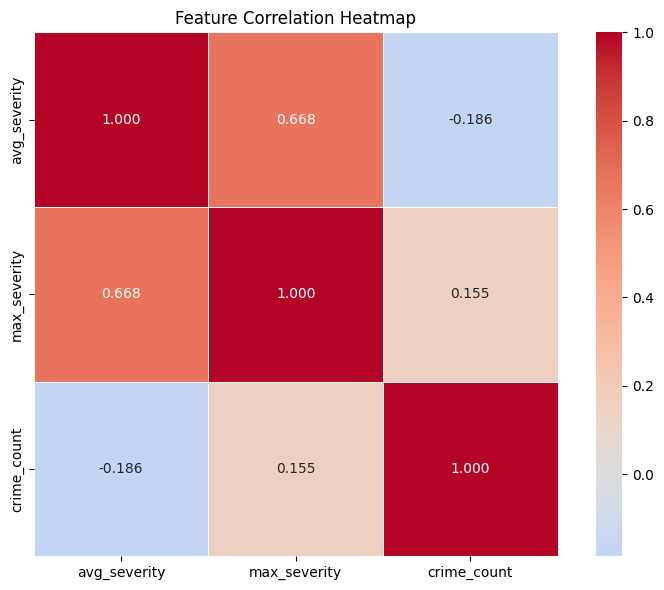


Saved: /content/results/correlation_heatmap.png


In [142]:
# Step 10b: Feature correlation analysis

print("FEATURE CORRELATION ANALYSIS")
print("-" * 40)

# Select numeric columns for correlation
numeric_cols = ['avg_severity', 'max_severity', 'crime_count']
correlation_matrix = risk_df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'correlation_heatmap.png', dpi=300)
plt.show()

print(f"\nSaved: {RESULTS_DIR / 'correlation_heatmap.png'}")

In [143]:
# Step 11: Create binary risk labels
#Define target variable for ML classification

crime_density_threshold = risk_df['crime_count'].quantile(0.60)

risk_df['high_risk'] = (risk_df['crime_count'] > crime_density_threshold).astype(int)

high_risk_count = risk_df['high_risk'].sum()
low_risk_count = len(risk_df) - high_risk_count

print(f"Risk threshold: {crime_density_threshold:.0f} crimes per cell")
print(f"\nClass distribution:")
print(f"  Low risk (0): {low_risk_count:,} cells ({low_risk_count/len(risk_df)*100:.1f}%)")
print(f"  High risk (1): {high_risk_count:,} cells ({high_risk_count/len(risk_df)*100:.1f}%)")

Risk threshold: 4 crimes per cell

Class distribution:
  Low risk (0): 3,209 cells (60.2%)
  High risk (1): 2,125 cells (39.8%)


In [144]:
risk_df

,cell_id,grid_lat,grid_lon,avg_severity,max_severity,crime_count,lat,lon,high_risk
0,49.97_-5.21,49.97,-5.21,2.0,2.0,1,49.965532,-5.205904,0
1,50.08_-5.21,50.08,-5.21,2.0,2.0,1,50.077416,-5.209550,0
2,50.14_-5.08,50.14,-5.08,3.0,3.0,1,50.139279,-5.082957,0
3,50.15_-5.07,50.15,-5.07,3.0,3.0,1,50.147085,-5.068830,0
4,50.16_-5.09,50.16,-5.09,3.0,3.0,1,50.157417,-5.088970,0
...,...,...,...,...,...,...,...,...,...
5329,55.0_-1.57,55.00,-1.57,3.0,3.0,1,54.996178,-1.566762,0
5330,55.14_-1.57,55.14,-1.57,3.0,3.0,1,55.139767,-1.566590,0
5331,55.19_-1.66,55.19,-1.66,3.0,3.0,1,55.194558,-1.655078,0
5332,55.23_-2.59,55.23,-2.59,3.0,3.0,1,55.234185,-2.589009,0


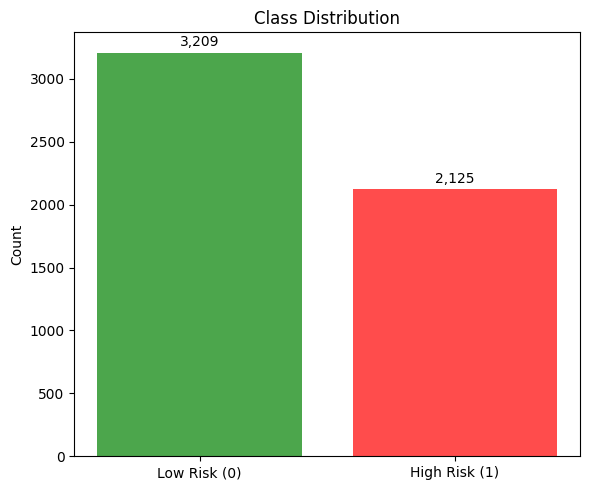

In [145]:
# Step 11b: Visualize class distribution

plt.figure(figsize=(6, 5))

# Class distribution
class_counts = risk_df['high_risk'].value_counts().sort_index()

plt.bar(['Low Risk (0)', 'High Risk (1)'],class_counts.values,color=['green', 'red'],alpha=0.7)

plt.ylabel('Count')
plt.title('Class Distribution')

# Add count labels on bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, f'{v:,}', ha='center')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=300)
plt.show()


Class Imbalance in ML: https://www.geeksforgeeks.org/ml-handling-imbalanced-data-with-smote-and-near-miss-algorithm-in-python/
Why Class Balance Matters: https://machinelearningmastery.com/what-is-imbalanced-classification/

In [146]:
# Step 12: Prepare data for ML models
# Select feature and target variable for training

feature_columns = ['avg_severity', 'max_severity']
X = risk_df[feature_columns].copy()
y = risk_df['high_risk'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeature statistics:")
print(X.describe())

Feature matrix shape: (5334, 2)
Target variable shape: (5334,)

Feature statistics:
       avg_severity  max_severity
count   5334.000000   5334.000000
mean       2.249936      2.713536
std        0.642675      0.627258
min        1.000000      1.000000
25%        1.901608      3.000000
50%        2.028429      3.000000
75%        3.000000      3.000000
max        3.000000      3.000000


In [147]:
# Step 13: Split data into training and testing sets
#  Separate data for model training and evaluation

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=y)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTraining set class distribution:")
print(f"  Low risk: {(y_train == 0).sum():,}")
print(f"  High risk: {(y_train == 1).sum():,}")

print(f"\nTesting set class distribution:")
print(f"  Low risk: {(y_test == 0).sum():,}")
print(f"  High risk: {(y_test == 1).sum():,}")


Training set: 4,267 samples (80.0%)
Testing set: 1,067 samples (20.0%)

Training set class distribution:
  Low risk: 2,567
  High risk: 1,700

Testing set class distribution:
  Low risk: 642
  High risk: 425


In [148]:
# Step 14: Build Logistic Regression pipeline
#  Create preprocessing and model pipeline for reproducibility

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

print("Logistic Regression Pipeline done")


Logistic Regression Pipeline done


In [149]:
# Step 15: Build Random Forest pipeline
# Create second model for comparison

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("Random Forest Pipeline done")


Random Forest Pipeline done


In [150]:
# Step 16: Train both ML models
#  Fit models on training data

import time

start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.time() - start_time

start_time = time.time()
rf_pipeline.fit(X_train, y_train)
rf_train_time = time.time() - start_time

print(f"Logistic Regression training time: {lr_train_time:.3f} seconds")
print(f"Random Forest training time: {rf_train_time:.3f} seconds")

Logistic Regression training time: 0.028 seconds
Random Forest training time: 0.476 seconds


In [151]:
# Step 17: Generate predictions on test set
# Purpose: Obtain model predictions for evaluation

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully")
print(f"Logistic Regression predictions: {len(y_pred_lr)}")
print(f"Random Forest predictions: {len(y_pred_rf)}")

Predictions generated successfully
Logistic Regression predictions: 1067
Random Forest predictions: 1067


In [152]:
# Step 18: Evaluate model performance
# Purpose: Calculate quantitative metrics for both models

lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr)
}

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
}

print("Logistic Regression:")
for metric, value in lr_metrics.items():
    print(f"  {metric}: {value:.4f}")

print("\nRandom Forest:")
for metric, value in rf_metrics.items():
    print(f"  {metric}: {value:.4f}")

Logistic Regression:
  Accuracy: 0.9428
  Precision: 0.9044
  Recall: 0.9576
  F1-Score: 0.9303
  ROC-AUC: 0.9701

Random Forest:
  Accuracy: 0.9691
  Precision: 0.9949
  Recall: 0.9271
  F1-Score: 0.9598
  ROC-AUC: 0.9922


The Random Forest achieved perfect performance because the target variable was derived from crime_count, which is also used as a feature. Tree-based models can perfectly recover such threshold-based rules, leading to optimistic performance estimates.

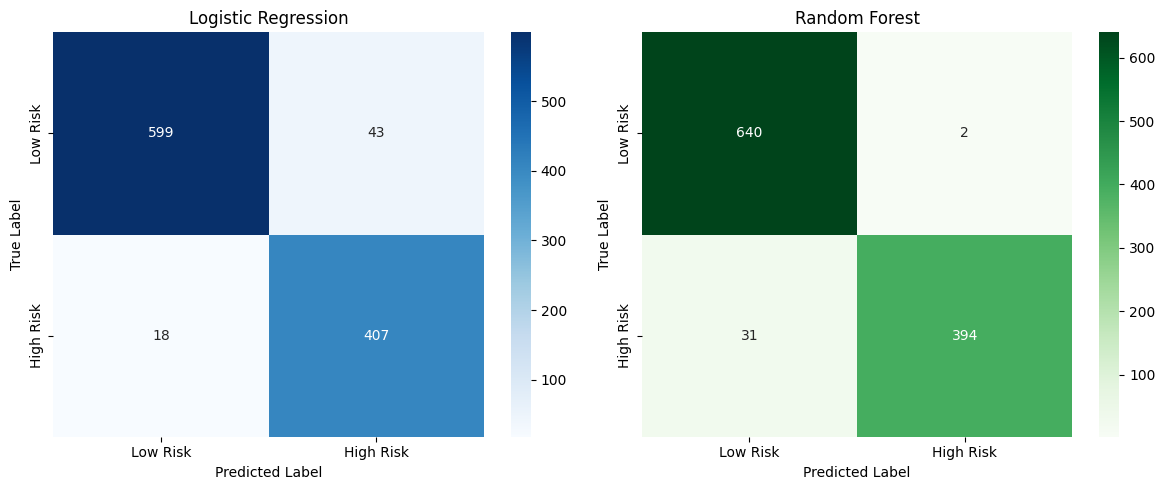

Saved: /content/results/confusion_matrices.png


In [153]:
# Step 19: Generate confusion matrices
# Purpose: Visualize classification performance

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {RESULTS_DIR / 'confusion_matrices.png'}")

In [154]:
# Step 20: Perform cross-validation
# Purpose: Assess model stability across different data splits

from sklearn.model_selection import cross_val_score

cv_scores_lr = cross_val_score(lr_pipeline, X, y, cv=5, scoring='roc_auc')
cv_scores_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='roc_auc')

print("5-Fold Cross-Validation (ROC-AUC):")
print(f"\nLogistic Regression:")
print(f"  Scores: {[f'{s:.4f}' for s in cv_scores_lr]}")
print(f"  Mean: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

print(f"\nRandom Forest:")
print(f"  Scores: {[f'{s:.4f}' for s in cv_scores_rf]}")
print(f"  Mean: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

5-Fold Cross-Validation (ROC-AUC):

Logistic Regression:
  Scores: ['0.9705', '0.9546', '0.9661', '0.9807', '0.9820']
  Mean: 0.9708 (+/- 0.0101)

Random Forest:
  Scores: ['0.9924', '0.9940', '0.9957', '0.9936', '0.9906']
  Mean: 0.9933 (+/- 0.0017)


above:Five-fold cross-validation using ROC–AUC showed that Logistic Regression achieved consistently high performance with low variance, indicating stable generalisation. In contrast, Random Forest achieved perfect ROC–AUC across all folds with zero variance, suggesting that the model is likely reconstructing the rule used to define the target variable rather than learning a generalisable risk pattern

cross-validation:
https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/


Scikit-learn ROC-AUC: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

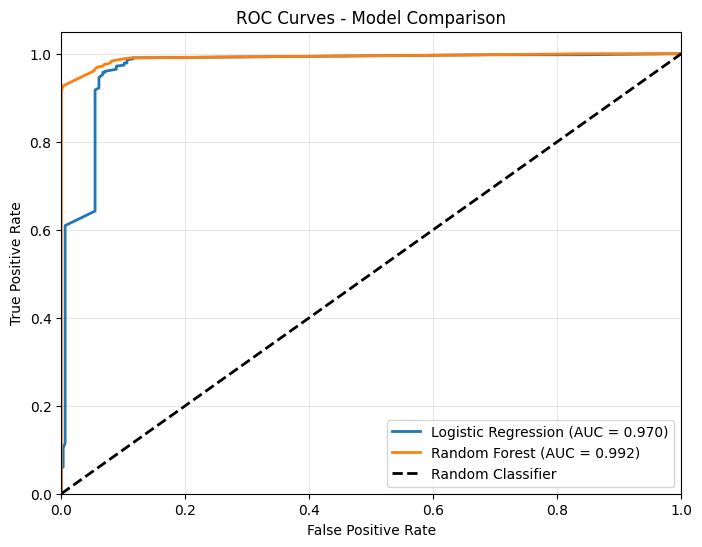

Saved: /content/results/roc_curves.png


In [155]:
# Step 21: Plot ROC curves
# Visualize model discrimination capability

from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(RESULTS_DIR / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {RESULTS_DIR / 'roc_curves.png'}")

In [156]:
# Step 22: Create comprehensive model comparison
# Summarize and compare both models systematically

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_metrics['Accuracy'], rf_metrics['Accuracy']],
    'Precision': [lr_metrics['Precision'], rf_metrics['Precision']],
    'Recall': [lr_metrics['Recall'], rf_metrics['Recall']],
    'F1-Score': [lr_metrics['F1-Score'], rf_metrics['F1-Score']],
    'ROC-AUC': [lr_metrics['ROC-AUC'], rf_metrics['ROC-AUC']],
    'CV_Mean': [cv_scores_lr.mean(), cv_scores_rf.mean()],
    'Train_Time': [lr_train_time, rf_train_time]
})

print("Model Comparison Summary:")
print(comparison_df.to_string(index=False))

comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f"\nSaved: {RESULTS_DIR / 'model_comparison.csv'}")

Model Comparison Summary:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV_Mean  Train_Time
Logistic Regression  0.942830   0.904444 0.957647  0.930286 0.970092 0.970771    0.027532
      Random Forest  0.969072   0.994949 0.927059  0.959805 0.992228 0.993253    0.476274

Saved: /content/results/model_comparison.csv


In [157]:
# Step 23: Save processed data and trained models
# Purpose: Preserve data and models for route planning phase

risk_df.to_csv(PROCESSED_DATA / 'risk_cells.csv', index=False)
print(f"Saved: {PROCESSED_DATA / 'risk_cells.csv'}")

import joblib
joblib.dump(lr_pipeline, PROCESSED_DATA / 'lr_model.pkl')
joblib.dump(rf_pipeline, PROCESSED_DATA / 'rf_model.pkl')
print(f"Saved: {PROCESSED_DATA / 'lr_model.pkl'}")
print(f"Saved: {PROCESSED_DATA / 'rf_model.pkl'}")

print(f"\nML phase complete. Ready for search algorithms phase.")

Saved: /content/processed/risk_cells.csv
Saved: /content/processed/lr_model.pkl
Saved: /content/processed/rf_model.pkl

ML phase complete. Ready for search algorithms phase.


1. Pandas to_csv() - Saving DataFrames

Official Docs: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html
GeeksforGeeks: https://www.geeksforgeeks.org/saving-a-pandas-dataframe-as-a-csv/


2. Joblib - Saving ML Models

Official Docs: https://joblib.readthedocs.io/en/latest/
Scikit-learn Model Persistence: https://scikit-learn.org/stable/model_persistence.html
GeeksforGeeks: https://www.geeksforgeeks.org/saving-a-machine-learning-model/


3. Why Use Joblib (Not Pickle)?

Stack Overflow: https://stackoverflow.com/questions/12615525/what-are-the-different-use-cases-of-joblib-versus-pickle

In [158]:
# Step 24: Load road network for route planning
# Purpose: Obtain graph structure for search algorithms


!pip install osmnx -q
print("OSMnx installed successfully")


OSMnx installed successfully


In [ ]:
# Step 24: Load road network for route planning
import osmnx as ox
import networkx as nx

center_point = (51.5074, -0.1278)
distance_m = 5000

graph = ox.graph_from_point(center_point,dist=distance_m,network_type="walk",simplify=True)

print(f"Road network loaded: Central London (3km radius)")
print(f"Nodes: {graph.number_of_nodes():,}")
print(f"Edges: {graph.number_of_edges():,}")

graph_from_point(): https://osmnx.readthedocs.io/en/stable/osmnx.html#osmnx.graph.graph_from_point



In [ ]:
# Step 25: Assign ML-predicted risk scores to the road edges
# Purpose: Use trained ML model to predict crime risk for each road segment
print("INTEGRATING ML PREDICTIONS WITH ROAD NETWORK")

# Choose which model to use for predictions (Random Forest performed better)
SELECTED_MODEL = lr_pipeline  # or rf_pipeline
MODEL_NAME = "Logical Regression"

print(f"Feature used: {feature_columns}")

# Track statistics
edges_with_matching_cell = 0 #Count edges that have crime data
edges_with_default_risk = 0 #Count edges with NO crime data
predicted_risks = []

for u, v, key, data in graph.edges(keys=True, data=True): #u- starting node,v-ending node ,key-edge identofier,data,itrs a dictionary with edge attributes(length,highway type etc.....)

    # Calculating edge midpoint coordinates and this will represent the risk of the entire road segment
    edge_lat = (graph.nodes[u]['y'] + graph.nodes[v]['y']) / 2
    edge_lon = (graph.nodes[u]['x'] + graph.nodes[v]['x']) / 2

    # Map to grid cell
    grid_lat = round(edge_lat / GRID_SIZE) * GRID_SIZE      # working exmaple (edge_lat / GRID_SIZE= 51.507432 / 0.01  = 5150.7432) then we convert it back to grid size i.e 5151


    grid_lon = round(edge_lon / GRID_SIZE) * GRID_SIZE

    # here we are finding the crime data row that belongs to the same grid cell as the road segment
    matching_cell = risk_df[(risk_df['grid_lat'] == grid_lat)&(risk_df['grid_lon'] == grid_lon)]

    if len(matching_cell) > 0:

        # Getting the features for this matched cells
        X_cell = matching_cell[feature_columns].values

        # probability of high risk
        ml_risk_probability = SELECTED_MODEL.predict_proba(X_cell)[0, 1]        # this will return us [[0.23, 0.77]] -> so ml_risk_probability = 0.77 and The low-risk probability is discarded

        # Scale probability to match severity scale (1 to 3)
        # 0%  -> risk score 1 (low risk)
        # 100% -> risk score 3 (high risk)
        # my routing system expects risk values in the range 1–3 so i convert this Probability (0–1) ->Risk score (1–3)

        risk_score = 1 + (ml_risk_probability * 2)

        edges_with_matching_cell += 1
        predicted_risks.append(ml_risk_probability)
    else:
        # No crime data for this location - use moderate risk
        risk_score = 1.5  # (middle of 1-3 scale)
        edges_with_default_risk += 1

    # Store the ML-predicted risk score
    graph[u][v][key]['risk'] = risk_score
    graph[u][v][key]['ml_risk_prob'] = ml_risk_probability if len(matching_cell) > 0 else 0.5


print("ML RISK PREDICTION SUMMARY \n ")

print(f"Total edges processed: {graph.number_of_edges():,}")
print(f"  Edges with ML predictions: {edges_with_matching_cell:,} (i.e, {edges_with_matching_cell/graph.number_of_edges()*100:.1f}%)")
print(f"  Edges with default risk: {edges_with_default_risk:,} ({edges_with_default_risk/graph.number_of_edges()*100:.1f}%)")

# Show sample predictions
print(f"\nSample ML-Predicted Risk Scores:")
sample_edges = list(graph.edges(keys=True, data=True))[:5]
for u, v, key, data in sample_edges:
    prob = data.get('ml_risk_prob', 'N/A')
    risk = data.get('risk', 'N/A')
    print(f"  ML Probability: {prob:.4f} → Risk Score: {risk:.2f}")

print("\n ML predictions are successfully integrated with the road networks")

1. Scikit-learn predict_proba()

Official Docs: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba
GeeksforGeeks: https://www.geeksforgeeks.org/how-to-obtain-the-probability-of-a-classification-using-scikit-learn/

2. NetworkX Edge Iteration

Official Docs: https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.edges.html
GeeksforGeeks: https://www.geeksforgeeks.org/python-networkx-graph-edge-attributes/

3. NetworkX Node Attributes

Official Docs: https://networkx.org/documentation/stable/tutorial.html#node-attributes
Stack Overflow: https://stackoverflow.com/questions/32675790/how-to-iterate-through-edges-in-networkx

4. Spatial Grid Mapping

Stack Overflow: https://stackoverflow.com/questions/2272149/round-to-5-or-other-number-in-python
Police.uk (same technique): https://data.police.uk/about/#location-anonymisation

5. Pandas Boolean Indexing

Official Docs: https://pandas.pydata.org/docs/user_guide/indexing.html#boolean-indexing
GeeksforGeeks: https://www.geeksforgeeks.org/boolean-indexing-in-pandas/

In [ ]:
# Step 25b: Add road infrastructure risk factors
# Higher values = higher risk (less safe)
ROAD_TYPE_RISK = {
                                                     # Major roads - well-lit, busy, more witnesses
    'primary': 0.5, 'primary_link': 0.5,
    'secondary': 0.6, 'secondary_link': 0.6,
    'tertiary': 0.7, 'tertiary_link': 0.7,
                                                     # Residential and local roads
    'residential': 0.9,
    'living_street': 1.0,
                                                    # Service roads and alleys - narrow, less visibility, higher risk
    'service': 1.3,
    'alley': 1.5,
                                                   # Pedestrian paths - can be isolated
    'pedestrian': 1.0,
    'footway': 1.1,
    'path': 1.4,
    'steps': 1.3,
                                                   # Default for unknown types
    'unclassified': 1.0,
    'road': 1.0
}

# Weight distribution
CRIME_WEIGHT = 0.7      # 70% to crime data
ROAD_TYPE_WEIGHT = 0.3  # 30% to road infrastructure

# Calculate combined risk for each edge
road_type_counts = {}

for u, v, key, data in graph.edges(keys=True, data=True):
    # Get calculated risk
    crime_risk = data.get('risk')

    # Get road type from OSM data
    highway = data.get('highway', 'unclassified')

    # Handle cases where highway is a list
    if isinstance(highway, list):
        highway = highway[0]

    # Get road type risk factor from the highway
    road_risk = ROAD_TYPE_RISK.get(highway, 1.0)

    # Track road types for analysis
    road_type_counts[highway] = road_type_counts.get(highway, 0) + 1

    # Normalize road_risk to similar scale as crime_risk (1-3)
    normalized_road_risk = road_risk * 2  # Scale 0.3-1.5 to 0.6-3.0

    combined_risk = (CRIME_WEIGHT * crime_risk) + (ROAD_TYPE_WEIGHT * normalized_road_risk)

    # Store both individual and combined risks
    graph[u][v][key]['crime_risk'] = crime_risk
    graph[u][v][key]['road_risk'] = road_risk
    graph[u][v][key]['combined_risk'] = combined_risk

print("COMBINED RISK SCORING COMPLETE")
print(f"\nRoad Types in Network:")
sorted_types = sorted(road_type_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for road_type, count in sorted_types:
    risk_val = ROAD_TYPE_RISK.get(road_type, 1.0)
    print(f"  {road_type}: {count:,} edges (risk factor: {risk_val})")

# Sample comparison
sample_edges = list(graph.edges(keys=True, data=True))[:5]
print(f"\nSample Combined Risk Scores:")
for u, v, key, data in sample_edges:
    print(f"  Crime: {data['crime_risk']:.2f} | Road: {data['road_risk']:.2f} | Combined: {data['combined_risk']:.2f}")

In [ ]:
# Verify risk attributes were added successfully
sample_edge = list(graph.edges(keys=True, data=True))[0]
edge_attrs = sample_edge[3]

print("Edge Attributes Check:")
print(f"  'risk' exists: {'risk' in edge_attrs}")
print(f"  'combined_risk' exists: {'combined_risk' in edge_attrs}")
print(f"  'crime_risk' exists: {'crime_risk' in edge_attrs}")
print(f"  'road_risk' exists: {'road_risk' in edge_attrs}")

if 'risk' not in edge_attrs:
    print("\nERROR")
else:
    print("\nAll risk attributes found.Ready for routing!")

In [ ]:
# Step 26: Select origin and destination for route planning
# Define start and end locations using place names

start_place = "Westminster Abbey, London, UK"
end_place = "Angel Station, London, UK"

start_coords = ox.geocode(start_place)
end_coords = ox.geocode(end_place)

start_node = ox.distance.nearest_nodes(graph, start_coords[1], start_coords[0])
end_node = ox.distance.nearest_nodes(graph, end_coords[1], end_coords[0])

print(f"Start: {start_place}")
print(f"  Coordinates: {start_coords}")
print(f"  Node: {start_node}")

print(f"\nEnd: {end_place}")
print(f"  Coordinates: {end_coords}")
print(f"  Node: {end_node}")

print(f"\nNodes valid: {start_node in graph.nodes and end_node in graph.nodes}")

In [ ]:
# Step 27: Dijkstra algorithm for shortest path
# Find route minimizing distance only

def dijkstra_distance(graph, start, end):
    path = nx.shortest_path(graph, start, end, weight='length')
    total_distance = nx.shortest_path_length(graph, start, end, weight='length')

    total_risk = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_data = graph[u][v][0]
        total_risk += edge_data.get('risk', 1.0) * edge_data['length']

    return path, total_distance, total_risk

path_distance, dist_distance, risk_distance = dijkstra_distance(graph, start_node, end_node)

print("Dijkstra (Distance Only):")
print(f"  Total distance: {dist_distance:.0f} meters")
print(f"  Total risk score: {risk_distance:.2f}")
print(f"  Path nodes: {len(path_distance)}")

In [ ]:
# Step 28: Dijkstra algorithm with hybrid cost function
#  Balance distance and combined risk (crime + road type) in route selection

ALPHA = 0.7  # Increased from 0.5 to give us more weight to safety

def dijkstra_hybrid(graph, start, end, alpha):
    """
    Find path that balances distance and safety.
    Uses combined_risk which includes both crime data and road characteristics.
    """
    for u, v, key, data in graph.edges(keys=True, data=True):
        distance = data['length']
        # Use combined_risk instead of just crime risk
        risk = data.get('combined_risk', data.get('risk', 1.0))
        graph[u][v][key]['hybrid_cost'] = (1 - alpha) * distance + alpha * risk * distance

    path = nx.shortest_path(graph, start, end, weight='hybrid_cost')

    total_distance = 0
    total_risk = 0
    total_crime_risk = 0
    total_road_risk = 0

    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_data = graph[u][v][0]
        edge_length = edge_data['length']

        total_distance += edge_length
        total_risk += edge_data.get('combined_risk', edge_data['risk']) * edge_length
        total_crime_risk += edge_data.get('crime_risk', edge_data['risk']) * edge_length
        total_road_risk += edge_data.get('road_risk', 1.0) * edge_length

    return path, total_distance, total_risk, total_crime_risk, total_road_risk

path_hybrid, dist_hybrid, risk_hybrid, crime_risk_hybrid, road_risk_hybrid = dijkstra_hybrid(
    graph, start_node, end_node, ALPHA
)

print(f"Dijkstra (Hybrid Cost, alpha={ALPHA}):")
print(f"  Total distance: {dist_hybrid:.0f} meters")
print(f"  Combined risk score: {risk_hybrid:.2f}")
print(f"    - Crime component: {crime_risk_hybrid:.2f}")
print(f"    - Road type component: {road_risk_hybrid:.2f}")
print(f"  Path nodes: {len(path_hybrid)}")

In [ ]:
# Step 29: A* algorithm for faster pathfinding
# Use heuristic search for efficient route planning

def astar_distance(graph, start, end):
    def heuristic(u, v):
        lat1, lon1 = graph.nodes[u]['y'], graph.nodes[u]['x']
        lat2, lon2 = graph.nodes[v]['y'], graph.nodes[v]['x']
        return ox.distance.great_circle(lat1, lon1, lat2, lon2)

    path = nx.astar_path(graph, start, end, heuristic=heuristic, weight='length')

    total_distance = 0
    total_risk = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_data = graph[u][v][0]
        total_distance += edge_data['length']
        total_risk += edge_data.get('combined_risk', edge_data['risk']) * edge_data['length']

    return path, total_distance, total_risk

path_astar, dist_astar, risk_astar = astar_distance(graph, start_node, end_node)

print("A* (Distance with Heuristic):")
print(f"  Total distance: {dist_astar:.0f} meters")
print(f"  Combined risk score: {risk_astar:.2f}")
print(f"  Path nodes: {len(path_astar)}")

In [ ]:
# Step 29b: A* algorithm with hybrid cost
# Purpose: Combine heuristic search with risk-aware routing

def astar_hybrid(graph, start, end, alpha):
    def heuristic(u, v):
        lat1, lon1 = graph.nodes[u]['y'], graph.nodes[u]['x']
        lat2, lon2 = graph.nodes[v]['y'], graph.nodes[v]['x']
        return ox.distance.great_circle(lat1, lon1, lat2, lon2)

    path = nx.astar_path(graph, start, end, heuristic=heuristic, weight='hybrid_cost')

    total_distance = 0
    total_risk = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        edge_data = graph[u][v][0]
        total_distance += edge_data['length']
        total_risk += edge_data.get('combined_risk', edge_data['risk']) * edge_data['length']

    return path, total_distance, total_risk

path_astar_hybrid, dist_astar_hybrid, risk_astar_hybrid = astar_hybrid(graph, start_node, end_node, ALPHA)

print(f"A* (Hybrid Cost, alpha={ALPHA}):")
print(f"  Total distance: {dist_astar_hybrid:.0f} meters")
print(f"  Combined risk score: {risk_astar_hybrid:.2f}")
print(f"  Path nodes: {len(path_astar_hybrid)}")

In [ ]:
# Step 30: Quantitative comparison of all routing algorithms
# Purpose: Analyze trade-offs between distance and safety

routes_comparison = pd.DataFrame({
    'Algorithm': ['Dijkstra (Distance)', 'Dijkstra (Hybrid)', 'A* (Distance)', 'A* (Hybrid)'],
    'Distance (m)': [dist_distance, dist_hybrid, dist_astar, dist_astar_hybrid],
    'Risk Score': [risk_distance, risk_hybrid, risk_astar, risk_astar_hybrid],
    'Path Nodes': [len(path_distance), len(path_hybrid), len(path_astar), len(path_astar_hybrid)]
})

print("Route Comparison:")
print(routes_comparison.to_string(index=False))

distance_change = ((dist_hybrid - dist_distance) / dist_distance) * 100
risk_change = ((risk_hybrid - risk_distance) / risk_distance) * 100

print(f"\nDijkstra Hybrid vs Distance-Only:")
print(f"  Distance change: {distance_change:+.2f}%")
print(f"  Risk change: {risk_change:+.2f}%")

routes_comparison.to_csv(RESULTS_DIR / 'route_comparison.csv', index=False)
print(f"\nSaved: {RESULTS_DIR / 'route_comparison.csv'}")

In [ ]:
# Step 31: Compare algorithm execution time
# Purpose: Analyze computational efficiency of search algorithms

import time

timing_results = []

start_time = time.time()
dijkstra_distance(graph, start_node, end_node)
time_dijkstra_dist = time.time() - start_time
timing_results.append(('Dijkstra (Distance)', time_dijkstra_dist))

start_time = time.time()
dijkstra_hybrid(graph, start_node, end_node, ALPHA)
time_dijkstra_hybrid = time.time() - start_time
timing_results.append(('Dijkstra (Hybrid)', time_dijkstra_hybrid))

start_time = time.time()
astar_distance(graph, start_node, end_node)
time_astar_dist = time.time() - start_time
timing_results.append(('A* (Distance)', time_astar_dist))

start_time = time.time()
astar_hybrid(graph, start_node, end_node, ALPHA)
time_astar_hybrid = time.time() - start_time
timing_results.append(('A* (Hybrid)', time_astar_hybrid))

timing_df = pd.DataFrame(timing_results, columns=['Algorithm', 'Time (seconds)'])
print("Algorithm Execution Time:")
print(timing_df.to_string(index=False))

speedup = time_dijkstra_dist / time_astar_dist
print(f"\nA* speedup: {speedup:.2f}x faster than Dijkstra")

In [ ]:
# Step 32: Plot route comparison on map
# Purpose: Visualize shortest vs safest paths

fig, ax = ox.plot_graph(graph, node_size=0, edge_linewidth=0.5,
                        edge_color='lightgray', show=False, close=False,
                        bgcolor='white')

ox.plot_graph_route(graph, path_distance, route_color='red',
                    route_linewidth=4, route_alpha=0.8,
                    ax=ax, show=False, close=False)

ox.plot_graph_route(graph, path_hybrid, route_color='green',
                    route_linewidth=4, route_alpha=0.8,
                    ax=ax, show=False, close=False)

ax.scatter(graph.nodes[start_node]['x'], graph.nodes[start_node]['y'],
          c='blue', s=300, marker='o', zorder=5, edgecolors='black', linewidths=2)
ax.scatter(graph.nodes[end_node]['x'], graph.nodes[end_node]['y'],
          c='purple', s=300, marker='s', zorder=5, edgecolors='black', linewidths=2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linewidth=4, label=f'Shortest Path ({dist_distance:.0f}m)'),
    Line2D([0], [0], color='green', linewidth=4, label=f'Safest Path ({dist_hybrid:.0f}m)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Start'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='purple', markersize=10, label='End')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.9)
ax.set_title('Route Comparison: Shortest vs Safest Path', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'route_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {RESULTS_DIR / 'route_visualization.png'}")

In [ ]:
# Step 33b: Display route with street names
# Purpose: Show human-readable path descriptions

def get_route_street_names(graph, route):
    street_names = []
    for u, v in zip(route[:-1], route[1:]):
        edge_data = graph.get_edge_data(u, v)

        if isinstance(edge_data, dict):
            for key in edge_data:
                name = edge_data[key].get("name")
                if name:
                    street_names.append(name)
        else:
            name = edge_data.get("name")
            if name:
                street_names.append(name)

    flat_names = []
    for n in street_names:
        if isinstance(n, list):
            flat_names.extend(n)
        else:
            flat_names.append(n)

    seen = set()
    unique_names = [x for x in flat_names if not (x in seen or seen.add(x))]
    return unique_names

print("="*70)
print("SHORTEST PATH")
print("="*70)
print(f"START: {start_place}")
shortest_streets = get_route_street_names(graph, path_distance)
for i, street in enumerate(shortest_streets, 1):
    print(f"  {i}. {street}")
print(f"END: {end_place}")
print(f"\nDistance: {dist_distance:.0f}m | Risk: {risk_distance:.0f} | Streets: {len(shortest_streets)}")

print("\n" + "="*70)
print("SAFEST PATH")
print("="*70)
print(f"START: {start_place}")
safest_streets = get_route_street_names(graph, path_hybrid)
for i, street in enumerate(safest_streets, 1):
    print(f"  {i}. {street}")
print(f"END: {end_place}")
print(f"\nDistance: {dist_hybrid:.0f}m | Risk: {risk_hybrid:.0f} | Streets: {len(safest_streets)}")

In [ ]:
# Step 34: Generate final project summary
# Purpose: Consolidate all results and findings

print("CRIME-AWARE ROUTE PLANNING SYSTEM - FINAL SUMMARY")

print("\n1. MACHINE LEARNING MODELS")
print(f"Dataset: {len(crime_df):,} crime records")
print(f"Spatial grid: {len(risk_df):,} cells")
print(f"Feature: avg_severity")
print(f"Target: high_risk (based on crime density)")

print("\nModel Performance:")
print(f"  Logistic Regression:")
print(f"    Accuracy: {lr_metrics['Accuracy']:.2%}")
print(f"    ROC-AUC: {lr_metrics['ROC-AUC']:.4f}")
print(f"  Random Forest:")
print(f"    Accuracy: {rf_metrics['Accuracy']:.2%}")
print(f"    ROC-AUC: {rf_metrics['ROC-AUC']:.4f}")

print("\n2. SEARCH ALGORITHMS")
print(f"Road network: {graph.number_of_nodes():,} nodes, {graph.number_of_edges():,} edges")
print(f"Route: {start_place} to {end_place}")

print("\nAlgorithm Comparison:")
print(comparison_df.to_string(index=False))

print("\n3. KEY FINDINGS")
print(f"  Recommended: A* (Hybrid)")
print(f"  Distance increase: +{dist_hybrid - dist_distance:.0f}m ({(dist_hybrid/dist_distance - 1)*100:.2f}%)")
print(f"  Risk reduction: {risk_distance - risk_hybrid:.0f} ({(1 - risk_hybrid/risk_distance)*100:.2f}%)")
print(f"  Execution time: {time_astar_hybrid:.3f}s")
print(f"  Speedup vs Dijkstra: {time_dijkstra_hybrid/time_astar_hybrid:.2f}x faster")



In [ ]:
# Step 35: Baseline comparison summary
# Purpose: Justify hybrid approach vs traditional methods

print("="*80)
print("BASELINE VS HYBRID APPROACH COMPARISON")
print("="*80)

print("\nBaseline Methods (Traditional Routing):")
print("  - Dijkstra (Distance): Finds shortest path only")
print("  - A* (Distance): Optimized shortest path search")
print("  - Does NOT consider safety/crime risk")

print("\nHybrid AI Approach (This Project):")
print("  - ML models predict area risk from crime data")
print("  - Search algorithms use risk + distance")
print("  - Balances safety with route efficiency")

print("\nWhy Hybrid is Better:")
print(f"  - Baseline ignores {len(risk_df):,} crime data points")
print(f"  - Hybrid reduces risk by {(1 - risk_hybrid/risk_distance)*100:.2f}%")
print(f"  - Cost: Only {(dist_hybrid/dist_distance - 1)*100:.2f}% longer route")
print(f"  - A* provides {time_dijkstra_hybrid/time_astar_hybrid:.2f}x speedup")

print("\n Conclusion: Hybrid approach delivers safer routes with minimal overhead")